In [8]:
import pandas as pd
import numpy as np 
import shutil
import subprocess
from pathlib import Path
import sys
sys.path.append("D://Cropnuts")
from QC_Model_Predictions.predict import predict_chems
import pyodbc
import json

tensorflow version : 2.16.1


In [9]:
import os

import json
import joblib
import glob
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
print(f'tensorflow version : {tf.version.VERSION}')
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras.models import Sequential, Model
from sklearn.model_selection import train_test_split
from datetime import datetime
from sklearn.metrics import *
import sys
sys.path.append("D://Cropnuts/QC_Model_Predictions")
import utils

tensorflow version : 2.16.1


In [10]:
conn_lims = pyodbc.connect("Driver={SQL Server};"
                            "Server=192.168.5.18\CROPNUT;"
                            "Database=cropnuts;"
                            "uid=thomasTsuma;pwd=GR^KX$uRe9#JwLc6")

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\tommy\AppData\Local\Temp\ipykernel_45132\232176420.py:2: SyntaxWarning: invalid escape sequence '\C'
  "Server=192.168.5.18\CROPNUT;"


In [11]:
import mariadb
import sys

username = "scoring"
password = "idkltb93e0eomejp"
host = 'spectral-msql-jul-24-backup-do-user-2276924-0.b.db.ondigitalocean.com'
port = 25060
database="farmlabv3_live"
# schema="farmlabv3_live"
# schema="historical"
def get_db_cursor():
    try:
        conn = mariadb.connect(
            user=username,
            password=password,
            host=host,
            port=port,
            database=database
    
        )
        return conn
    except mariadb.Error as e:
        print(f"Error connecting to MariaDB Platform: {e}")
        sys.exit(1)

conn = get_db_cursor()
cur = conn.cursor()

In [12]:
subprocess.run(["python", "D://Cropnuts/opus_to_csv/cli.py", "-i", "D://Cropnuts/DSML147/outputFiles/opus_renamed", "-o", "D://Cropnuts/DSML147/outputFiles/opus_renamed", "-d", "['AB']"])

CompletedProcess(args=['python', 'D://Cropnuts/opus_to_csv/cli.py', '-i', 'D://Cropnuts/DSML147/outputFiles/opus_renamed', '-o', 'D://Cropnuts/DSML147/outputFiles/opus_renamed', '-d', "['AB']"], returncode=0)

In [13]:
spc = pd.read_csv([str(i) for i in Path("D://Cropnuts/DSML147/outputFiles/opus_renamed").rglob("**/*AB_quantized_spectra.csv")][-1],index_col=0)

In [14]:
def mean_dupes_drop_singles_filter_by_std( df, std_thres=0.03, filt_zeros=True):
    """ Within the SPC samples,  duplicates should be averaged, not dropped.
    This function:

    - averages the duplicates
    - calculates std over column
    -  filters the samples out with high std (high std could mean collection error)
    -  filters the samples out with 0 std (not a true duplicate)

    Parameters
    ----------
    :param: ``df`` : ``pd.DataFrame``
        Dataframe of SPC data.
    :param: ``std_thres`` : ``float``
        standard deviation threshold for acceptable data. Default = 0.01.
    :param: ``filt_zeros`` : ``bool``
        If True, filter out sample duplicates with a standard deviation of 0 --> unrealistic!

    Returns
    -------
    :return: ```pd.DataFrame``
        Dataframe in better shape.

    """
    # copy dataframe for std calculation
    df_std = df.copy(deep=True)
#     cls.__log.info("Shape of initial dataframe: %s", np.shape(df_std))

    # average duplicates
    df = df.groupby(df.index).mean()

    # calculate average std over column, maintain index
    df_std = df_std.groupby(df_std.index).std()
    # failed_indices = [(2138, 61433) ]
    # print(df_std.loc[failed_indices])
    # df_std =df_std.loc[failed_indices]
    # print(df.std(axis=0).sort_values(ascending =False).head(30))
    # calculate avg std series
    df_std = df_std.mean(axis=1)

    # create dataframe from avg std series
    df_std = pd.DataFrame(
        index=df_std.index.values, columns=["std"], data=df_std.values
    )
    print(df_std.sort_values(by='std',ascending =False).head())
    # print(df_std)
    df_std = df_std.dropna()
    # failed_indices = [(2138, 61433) ]  
    # df_std.loc[failed_indices]

#     cls.__log.info("Shape of dataframe w/o NaNs: %s", np.shape(df_std))

    # filter df by std, removing below thresh
    df_std = df_std[df_std["std"] < std_thres]
#     cls.__log.info("Shape of thresholded dataframe: %s", np.shape(df_std))

    if filt_zeros:
        df_std = df_std[df_std["std"] > 0]
#         cls.__log.info(
#             "Shape of thresholded dataframe with filtered zeros: %s",
#             np.shape(df_std),
#         )

    # merge the dataframes by index
    df_mrgd = pd.merge(df, df_std, left_index=True, right_index=True, how="outer")
#     cls.__log.info("Shape of merged dataframe by index: %s", np.shape(df_mrgd))

    # drop na's by row
    df_mrgd = df_mrgd.dropna()
#     cls.__log.info("Shape of merged dataframe w/o NaNs: %s", np.shape(df_mrgd))

    # drop std column
    df_mrgd = df_mrgd.drop(["std"], axis=1)

    return df_mrgd


In [15]:
spc_2 = spc.copy(deep=True)

In [16]:
spc_2.index = [str(i).split("_")[0] for i in spc_2.index]

In [17]:
spc_2 = mean_dupes_drop_singles_filter_by_std(spc_2)

                    std
TEST-DS1-0450  0.017115
TEST-DS1-0436  0.017115
TEST-DS1-0472  0.017115
TEST-DS1-0461  0.013172
TEST-DS1-0433  0.013172


<Axes: >

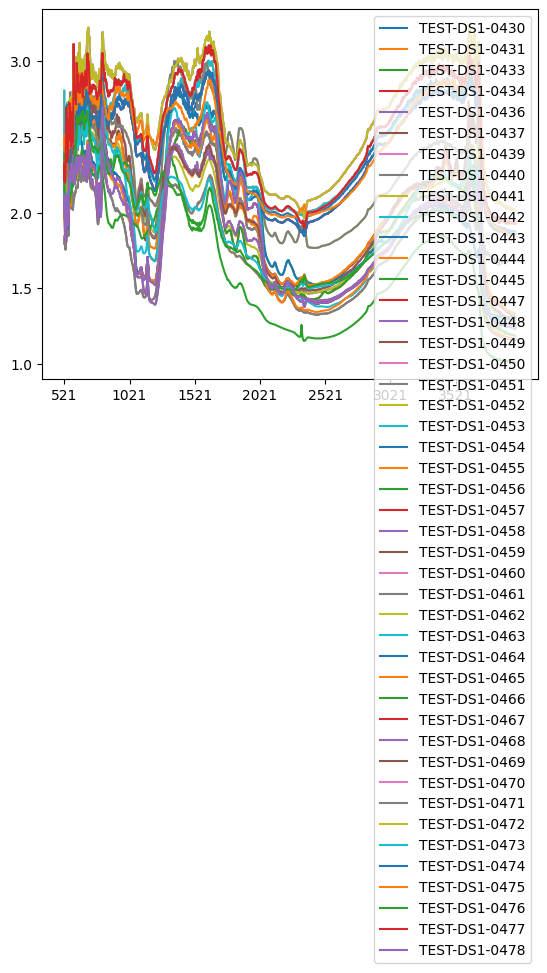

In [18]:
spc_2.T.plot()

In [19]:
chemicals = ['phosphorus', 'ph', 'calcium', 'magnesium', 'potassium','organic_carbon']

In [20]:
data = spc_2.copy(deep=True)

In [21]:
data = data.T.head(1728).T

In [22]:
base_path = "D://Cropnuts/QC_Model_Predictions/dl_models_all_chems_20210414/v2.2"

In [23]:
os.makedirs("D://Cropnuts/DSML147/outputFiles/preds",exist_ok=True)
df = pd.DataFrame(index=data.index)
for chemical in chemicals:
    print(chemical)
    preds_comb = pd.DataFrame()
    models_folder = Path(f"{base_path}/{chemical}/std")
    all_models = [x for x in models_folder.glob('**/*.hdf5')]

    
    new_indices = data.index



    for model_path in all_models:

        json_path = model_path.parent.parent / 'model.json'

        with open(json_path) as f:
            json_ = json.load(f)

        inputs = []

        for i in range(len(json_['Inputs'])):
            input_name = json_['Inputs'][i]['Name']
            train = data.copy(deep=True)

            for j in range(len(json_['Inputs'][i]['Pre-processing'])):
                key_ = json_['Inputs'][i]['Pre-processing'][j]['Name']
                if input_name == 'nir2':
                    input_name = 'nir.2'
                pickle_path = model_path.parent / 'preprocess' / f'input.{input_name}.{j}.{key_}.pickle'
                pickle_ = joblib.load(pickle_path)
                train = pickle_.fit_transform(train)

            inputs.append(train.values)

        tf.keras.backend.clear_session()
        model = tf.keras.models.load_model(model_path, compile=False)
        preds = pd.DataFrame(model(inputs).numpy())
        preds_comb = pd.concat([preds_comb, preds], axis=1)

    preds_comb = preds_comb.median(axis=1)
    preds_comb.index = new_indices
    df[chemical] = preds_comb.values
    
    


phosphorus

ph
calcium
magnesium
potassium
organic_carbon


In [24]:
df

,phosphorus,ph,calcium,magnesium,potassium,organic_carbon
TEST-DS1-0430,82.667015,7.297954,3526.988281,852.643311,608.648315,4.599232
TEST-DS1-0431,28.618593,5.152287,937.435791,244.123108,197.641449,2.168417
TEST-DS1-0433,45.309578,7.395707,3677.473389,746.329590,426.101227,4.636365
TEST-DS1-0434,39.776775,7.025331,1331.112305,289.013031,124.988091,1.758390
TEST-DS1-0436,36.796375,7.637722,3008.324463,758.375244,551.583679,5.001614
TEST-DS1-0437,49.113453,6.539593,1372.645386,274.915192,156.954132,1.765258
TEST-DS1-0439,82.667015,7.297954,3526.988281,852.643311,608.648315,4.599232
TEST-DS1-0440,28.618593,5.152287,937.435791,244.123108,197.641449,2.168417
TEST-DS1-0441,61.216961,5.009243,333.674622,68.222038,115.229713,1.596545
TEST-DS1-0442,45.309578,7.395707,3677.473389,746.329590,426.101227,4.636365


In [25]:
df['organic_matter'] = df['organic_carbon'] * 1.72

In [26]:
df.to_csv("outputFiles/preds/predictions.csv")

In [27]:
comparison_df = pd.read_csv("inputFiles/client_approval_settings.csv")    

In [28]:
def classifyResult(X, lim1, lim2, lim3):
    if X <= lim1:
        return "very low"
    elif X <= lim2:
        return "low"
    elif X <= lim3:
        return "optimum"
    else:
        return "high"

In [29]:
prediction_classes = pd.DataFrame()
for index, row in comparison_df.iterrows():
    barcode = row['barcode']
    crop = row['crop']
    client = row['client_name']
    farm = row['farm_name']
    ph = row['ph']
    phosphorus = row['phosphorus']
    potassium = row['potassium']
    organic_matter = row['Organic Matter']
    
    vindexes = pd.read_sql(f"""
        SELECT vIndexes.guide, Clients.client_id, Clients.client_name, LOWER(vIndexes.status_name) AS status_name, Crops.crop_name, vIndexes.crop_code, LOWER(vIndexes.Chemical_Name) AS chemical_name 
        FROM vIndexes 
        INNER JOIN Crops 
        ON Crops.crop_code = vIndexes.crop_code
        INNER JOIN Clients
        ON Clients.client_id = vIndexes.client_id
        WHERE 
        vIndexes.crop_name LIKE '%{crop}%' AND 
        chemical_name IN ('ph','organic matter','calcium') AND
        Clients.client_name LIKE '%{client}%' AND
        guide IS NOT NULL
    """,con=conn_lims)
    if len(vindexes) == 0:
        vindexes = pd.read_sql(f"""
        SELECT vIndexes.guide, Clients.client_id, Clients.client_name, LOWER(vIndexes.status_name) AS status_name, Crops.crop_name, vIndexes.crop_code, LOWER(vIndexes.Chemical_Name) AS chemical_name 
        FROM vIndexes 
        INNER JOIN Crops 
        ON Crops.crop_code = vIndexes.crop_code
        INNER JOIN Clients
        ON Clients.client_id = vIndexes.client_id
        WHERE 
        vIndexes.crop_name LIKE '%{crop}%' AND 
        chemical_name IN ('ph','organic matter','calcium') AND
        Clients.client_name LIKE '%FMAFS-National%' AND
        guide IS NOT NULL
        """,con=conn_lims)
    vindexes.chemical_name =  [str(i).replace(" ","_") for i in vindexes.chemical_name]
    vindexes.chemical_name = [i.strip().replace(" ","_").replace(".","").replace("(","").replace(")","") for i in vindexes.chemical_name]
    vindexes = vindexes.drop_duplicates()
    
    # calcium_guides = vindexes.loc[vindexes['chemical_name']=='calcium']
    # calcium_guides = calcium_guides.drop_duplicates(subset='status_name')
    # calcium_guides = calcium_guides[['status_name','guide']]
    # calcium_guides = calcium_guides.set_index('status_name')
    # calcium_guides = calcium_guides.to_dict()
    
    # magnesium_guides = vindexes.loc[vindexes['chemical_name']=='magnesium']
    # magnesium_guides = magnesium_guides.drop_duplicates(subset='status_name')
    # magnesium_guides = magnesium_guides[['status_name','guide']]
    # magnesium_guides = magnesium_guides.set_index('status_name')
    # magnesium_guides = magnesium_guides.to_dict()
    
    organic_matter_guides = vindexes.loc[vindexes['chemical_name']=='organic_matter']
    organic_matter_guides = organic_matter_guides.drop_duplicates(subset='status_name')
    organic_matter_guides = organic_matter_guides[['status_name','guide']]
    organic_matter_guides = organic_matter_guides.set_index('status_name')
    organic_matter_guides = organic_matter_guides.to_dict()
    
    ph_guides = vindexes.loc[vindexes['chemical_name']=='ph']
    ph_guides = ph_guides.drop_duplicates(subset='status_name')
    ph_guides = ph_guides[['status_name','guide']]
    ph_guides = ph_guides.set_index('status_name')
    ph_guides = ph_guides.to_dict()

    crop_reports = df.loc[df.index == barcode]
    
    crop_reports['ph_classes'] = crop_reports['ph'].apply(classifyResult, args=(ph_guides['guide']['very low'],ph_guides['guide']['low'],ph_guides['guide']['high']))                                              
    crop_reports['organic_matter_classes'] = crop_reports['organic_matter'].apply(classifyResult, args=(organic_matter_guides['guide']['very low'],organic_matter_guides['guide']['low'],organic_matter_guides['guide']['high']))                                              
    # crop_reports['calcium_classes'] = crop_reports['calciumPercSat'].apply(classifyResult, args=(calcium_guides['guide']['very low'],calcium_guides['guide']['low'],calcium_guides['guide']['high']))
    # crop_reports['magnesium'] = crop_reports['magnesiumPercSat'].apply(classifyResult, args=((magnesium_guides['guide']['very low'],magnesium_guides['guide']['low'],magnesium_guides['guide']['critical'])))
    crop_reports['potassium_classes'] = crop_reports['potassium'].apply(classifyResult, args=(60,120,180))
    crop_reports['phosphorus_classes'] = crop_reports['phosphorus']

    prediction_classes = pd.concat([prediction_classes, crop_reports])
    print(crop_reports)


C:\Users\tommy\AppData\Local\Temp\ipykernel_45132\2539219264.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vindexes = pd.read_sql(f"""


               phosphorus        ph      calcium   magnesium   potassium  \
TEST-DS1-0430   82.667015  7.297954  3526.988281  852.643311  608.648315   

               organic_carbon  organic_matter ph_classes  \
TEST-DS1-0430        4.599232        7.910679       high   

              organic_matter_classes potassium_classes  phosphorus_classes  
TEST-DS1-0430                optimum              high           82.667015  


C:\Users\tommy\AppData\Local\Temp\ipykernel_45132\2539219264.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vindexes = pd.read_sql(f"""


               phosphorus        ph     calcium   magnesium   potassium  \
TEST-DS1-0431   28.618593  5.152287  937.435791  244.123108  197.641449   

               organic_carbon  organic_matter ph_classes  \
TEST-DS1-0431        2.168417        3.729678        low   

              organic_matter_classes potassium_classes  phosphorus_classes  
TEST-DS1-0431                optimum              high           28.618593  


C:\Users\tommy\AppData\Local\Temp\ipykernel_45132\2539219264.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vindexes = pd.read_sql(f"""


...

               phosphorus        ph     calcium   magnesium   potassium  \
TEST-DS1-0476   44.250153  4.421423  457.672638  226.645569  143.286575   

               organic_carbon  organic_matter ph_classes  \
TEST-DS1-0476        1.333554        2.293713        low   

              organic_matter_classes potassium_classes  phosphorus_classes  
TEST-DS1-0476                    low           optimum           44.250153  


C:\Users\tommy\AppData\Local\Temp\ipykernel_45132\2539219264.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vindexes = pd.read_sql(f"""


               phosphorus        ph      calcium   magnesium   potassium  \
TEST-DS1-0477   45.309635  7.395708  3677.472412  746.329285  426.100677   

               organic_carbon  organic_matter ph_classes  \
TEST-DS1-0477        4.636365        7.974548       high   

              organic_matter_classes potassium_classes  phosphorus_classes  
TEST-DS1-0477                optimum              high           45.309635  


C:\Users\tommy\AppData\Local\Temp\ipykernel_45132\2539219264.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vindexes = pd.read_sql(f"""


               phosphorus        ph      calcium   magnesium   potassium  \
TEST-DS1-0478   39.776871  7.025331  1331.112549  289.013123  124.988037   

               organic_carbon  organic_matter ph_classes  \
TEST-DS1-0478        1.758389         3.02443       high   

              organic_matter_classes potassium_classes  phosphorus_classes  
TEST-DS1-0478                optimum           optimum           39.776871  


In [30]:
comparison_df

,barcode,client_name,farm_name,crop,country_name,AEZ_name,ph,phosphorus,potassium,Organic Matter,...,PLANTING.3,PLANTING.4,TOP DRESS,TOP DRESS.1,TOP DRESS.2,TOP DRESS.3,TOP DRESS.4,Age,Plant density,Acres
0,TEST-DS1-0430,OCP Kenya,test,Coffee,Kenya,"Tropics, lowland; humid, no soil/terrain limit...",high,high,high,high,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TEST-DS1-0431,OCP Kenya,test,Coffee,Kenya,Land with severe soil/terrain limitations,optimum,high,optimum,optimum,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TEST-DS1-0432,OCP Kenya,test,Coffee,Kenya,"Tropics, lowland; humid, with soil/terrain lim...",low,high,low,low,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,MOP,NaN,NaN,NaN,NaN
3,TEST-DS1-0433,OCP Kenya,test,Coffee,Kenya,"Tropics, highland; sub-humid, no soil/terrain ...",high,optimum,high,high,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEST-DS1-0434,OCP Kenya,test,Coffee,Kenya,"Tropics, highland; sub-humid, with soil/terrai...",optimum,optimum,optimum,optimum,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,TEST-DS1-0435,OCP Kenya,test,Coffee,Kenya,"Tropics, highland; humid, no soil/terrain limi...",low,optimum,low,low,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,MOP,NaN,NaN,NaN,NaN
6,TEST-DS1-0436,OCP Kenya,test,Coffee,Kenya,"Tropics, highland; humid, with soil/terrain li...",high,low,high,high,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,TEST-DS1-0437,OCP Kenya,test,Coffee,Kenya,Dominantly hydromorphic soils,optimum,low,optimum,optimum,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,TEST-DS1-0438,OCP Kenya,test,Coffee,Kenya,"Tropics, lowland; sub-humid, with soil/terrain...",low,low,low,low,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,MOP,NaN,NaN,NaN,NaN
9,TEST-DS1-0439,OCP Kenya,test,Coffee,Kenya,"Tropics, lowland; sub-humid, no soil/terrain l...",high,high,high,high,...,NaN,NaN,22.6.12+ 3S+B+Zn,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
prediction_classes.to_csv("outputFiles/preds/opus_files_predicted_classes.csv")

In [32]:
prediction_classes

,phosphorus,ph,calcium,magnesium,potassium,organic_carbon,organic_matter,ph_classes,organic_matter_classes,potassium_classes,phosphorus_classes
TEST-DS1-0430,82.667015,7.297954,3526.988281,852.643311,608.648315,4.599232,7.910679,high,optimum,high,82.667015
TEST-DS1-0431,28.618593,5.152287,937.435791,244.123108,197.641449,2.168417,3.729678,low,optimum,high,28.618593
TEST-DS1-0433,45.309578,7.395707,3677.473389,746.329590,426.101227,4.636365,7.974548,high,optimum,high,45.309578
TEST-DS1-0434,39.776775,7.025331,1331.112305,289.013031,124.988091,1.758390,3.024430,high,optimum,optimum,39.776775
TEST-DS1-0436,36.796375,7.637722,3008.324463,758.375244,551.583679,5.001614,8.602777,high,high,high,36.796375
TEST-DS1-0437,49.113453,6.539593,1372.645386,274.915192,156.954132,1.765258,3.036243,optimum,optimum,optimum,49.113453
TEST-DS1-0439,82.667015,7.297954,3526.988281,852.643311,608.648315,4.599232,7.910679,high,optimum,high,82.667015
TEST-DS1-0440,28.618593,5.152287,937.435791,244.123108,197.641449,2.168417,3.729678,low,optimum,high,28.618593
TEST-DS1-0441,61.216961,5.009243,333.674622,68.222038,115.229713,1.596545,2.746058,low,low,low,61.216961
TEST-DS1-0442,45.309578,7.395707,3677.473389,746.329590,426.101227,4.636365,7.974548,high,optimum,high,45.309578


In [26]:
crops = pd.read_sql(f"SELECT id, LOWER(name) as name from crop c WHERE c.name IN {tuple(comparison_df['crop'])}",con=conn)

C:\Users\tommy\AppData\Local\Temp\ipykernel_5984\2637936010.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  crops = pd.read_sql(f"SELECT id, LOWER(name) as name from crop c WHERE c.name IN {tuple(comparison_df['crop'])}",con=conn)


In [27]:
crops

,id,name
0,1,maize
1,2,sorghum
2,5,coffee
3,6,rice
4,10,potatoes (irish)
5,15,beans
6,20,maize
7,40,potatoes (irish)
8,66,tomatoes (open field)
9,79,wheat


In [28]:
crops = crops.drop_duplicates(subset="name")

In [29]:
crops = crops.set_index("name")

In [30]:
crops_dict = crops.to_dict()

In [31]:
crops_dict

{'id': {'maize': 1,
  'sorghum': 2,
  'coffee': 5,
  'rice': 6,
  'potatoes (irish)': 10,
  'beans': 15,
  'tomatoes (open field)': 66,
  'wheat': 79,
  'bananas': 141}}

In [32]:
comparison_df['crop'] = [ i.lower() for i in comparison_df['crop'].values]

In [33]:
comparison_df['id'] = [ crops_dict['id'][i] for i in comparison_df['crop'].values ]

In [34]:
comparison_df['barcode-crop'] =  comparison_df['barcode'].astype("str")  +"-" + comparison_df['id'].astype("str")

In [35]:
comparison_df

,barcode,client_name,farm_name,crop,country_name,AEZ_name,ph,phosphorus,potassium,Organic Matter,...,PLANTING.2,PLANTING.3,PLANTING.4,TOP DRESS,TOP DRESS.1,TOP DRESS.2,TOP DRESS.3,TOP DRESS.4,id,barcode-crop
0,TEST-DS1-0020,OCP Kenya,test,maize,Kenya,"Tropics, lowland; humid, no soil/terrain limit...",high,high,high,high,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0020-1
1,TEST-DS1-0021,OCP Kenya,test,maize,Kenya,Land with severe soil/terrain limitations,optimum,high,optimum,optimum,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0021-1
2,TEST-DS1-0022,OCP Kenya,test,maize,Kenya,"Tropics, lowland; humid, with soil/terrain lim...",low,high,low,low,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0022-1
3,TEST-DS1-0023,OCP Kenya,test,maize,Kenya,"Tropics, highland; sub-humid, no soil/terrain ...",high,optimum,high,high,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0023-1
4,TEST-DS1-0024,OCP Kenya,test,maize,Kenya,"Tropics, highland; sub-humid, with soil/terrai...",optimum,optimum,optimum,optimum,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0024-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,TEST-DS1-0141,OCP Kenya,test,tomatoes (open field),Kenya,"Tropics, lowland; sub-humid, no soil/terrain l...",high,high,high,high,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0141-66
122,TEST-DS1-0142,OCP Kenya,test,tomatoes (open field),Kenya,"Tropics, lowland; semi-arid, no soil/terrain l...",optimum,high,optimum,optimum,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0142-66
123,TEST-DS1-0143,OCP Kenya,test,tomatoes (open field),Kenya,"Tropics, lowland; semi-arid, with soil/terrain...",low,high,low,low,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0143-66
124,TEST-DS1-0144,OCP Kenya,test,tomatoes (open field),Kenya,Desert/Arid climate,high,optimum,high,high,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0144-66


In [36]:
spectral_sample_crop = pd.read_sql(f"SELECT barcode, report_data FROM SpectralSampleCrop WHERE barcode IN {tuple(comparison_df['barcode-crop'].values)}",con=conn)

C:\Users\tommy\AppData\Local\Temp\ipykernel_5984\4208093381.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  spectral_sample_crop = pd.read_sql(f"SELECT barcode, report_data FROM SpectralSampleCrop WHERE barcode IN {tuple(comparison_df['barcode-crop'].values)}",con=conn)


In [37]:
spectral_sample_crop  = spectral_sample_crop.set_index("barcode")

In [38]:
report_data = pd.DataFrame()
for index, row in spectral_sample_crop.iterrows():
    report = row['report_data']
    report = json.loads(report)
    results = report[index]['results']
    results = pd.DataFrame(results)
    results['chemical_name'] = [ i.replace(" ","_").lower() for i in results['chemical_name'] ]
    results = results.loc[results['chemical_name'].isin(["ph","available_p","exchangeable_k","organic_matter"])]
    results['barcode'] = index
    results = results.replace("Very Low",0).replace("Low",1).replace("Optimum",2).replace("High",3).replace("Very High",3)
    results = results.replace("available_p","phosphorus").replace("exchangeable_k","potassium")  
    results = results.dropna(subset="status")
    report_data = pd.concat([report_data,results])


C:\Users\tommy\AppData\Local\Temp\ipykernel_5984\3561677619.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results = results.replace("Very Low",0).replace("Low",1).replace("Optimum",2).replace("High",3).replace("Very High",3)
C:\Users\tommy\AppData\Local\Temp\ipykernel_5984\3561677619.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results = results.replace("Very Low",0).replace("Low",1).replace("Optimum",2).replace("High",3).replace("Very High",3)
C:\Users\tommy\AppData\Local\Temp\ipykernel_5984\3561677619.py:10: Futur

In [39]:
report_data

,result,status,result_unit,chemical_name,barcode
0,7.60,3,None,ph,TEST-DS1-0020-1
1,>50,3,ppm,phosphorus,TEST-DS1-0020-1
2,882,3,ppm,potassium,TEST-DS1-0020-1
12,5.88,2,%,organic_matter,TEST-DS1-0020-1
0,6.60,2,None,ph,TEST-DS1-0021-1
...,...,...,...,...,...
12,5.57,2,%,organic_matter,TEST-DS1-0144-66
0,6.30,2,None,ph,TEST-DS1-0145-66
1,30-50,2,ppm,phosphorus,TEST-DS1-0145-66
2,126,2,ppm,potassium,TEST-DS1-0145-66


In [40]:
report_data = report_data.pivot_table(index="barcode", columns="chemical_name", values="status")
report_data = report_data.replace(0,"very low").replace(1,"low").replace(2,"optimum").replace(3,"high").replace(3,"very high")

In [41]:
report_data = report_data[['ph','phosphorus','potassium','organic_matter']]

In [42]:
report_data

chemical_name,ph,phosphorus,potassium,organic_matter
barcode,,,,
TEST-DS1-0020-1,high,high,high,optimum
TEST-DS1-0021-1,optimum,high,low,optimum
TEST-DS1-0023-1,optimum,optimum,high,optimum
TEST-DS1-0024-1,optimum,optimum,low,optimum
TEST-DS1-0026-1,optimum,low,high,optimum
...,...,...,...,...
TEST-DS1-0141-66,high,high,high,optimum
TEST-DS1-0142-66,optimum,high,optimum,optimum
TEST-DS1-0143-66,low,high,low,low


In [43]:
comparison_df

,barcode,client_name,farm_name,crop,country_name,AEZ_name,ph,phosphorus,potassium,Organic Matter,...,PLANTING.2,PLANTING.3,PLANTING.4,TOP DRESS,TOP DRESS.1,TOP DRESS.2,TOP DRESS.3,TOP DRESS.4,id,barcode-crop
0,TEST-DS1-0020,OCP Kenya,test,maize,Kenya,"Tropics, lowland; humid, no soil/terrain limit...",high,high,high,high,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0020-1
1,TEST-DS1-0021,OCP Kenya,test,maize,Kenya,Land with severe soil/terrain limitations,optimum,high,optimum,optimum,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0021-1
2,TEST-DS1-0022,OCP Kenya,test,maize,Kenya,"Tropics, lowland; humid, with soil/terrain lim...",low,high,low,low,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0022-1
3,TEST-DS1-0023,OCP Kenya,test,maize,Kenya,"Tropics, highland; sub-humid, no soil/terrain ...",high,optimum,high,high,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0023-1
4,TEST-DS1-0024,OCP Kenya,test,maize,Kenya,"Tropics, highland; sub-humid, with soil/terrai...",optimum,optimum,optimum,optimum,...,NaN,NaN,NaN,UREA,NaN,NaN,NaN,NaN,1,TEST-DS1-0024-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,TEST-DS1-0141,OCP Kenya,test,tomatoes (open field),Kenya,"Tropics, lowland; sub-humid, no soil/terrain l...",high,high,high,high,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0141-66
122,TEST-DS1-0142,OCP Kenya,test,tomatoes (open field),Kenya,"Tropics, lowland; semi-arid, no soil/terrain l...",optimum,high,optimum,optimum,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0142-66
123,TEST-DS1-0143,OCP Kenya,test,tomatoes (open field),Kenya,"Tropics, lowland; semi-arid, with soil/terrain...",low,high,low,low,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0143-66
124,TEST-DS1-0144,OCP Kenya,test,tomatoes (open field),Kenya,Desert/Arid climate,high,optimum,high,high,...,NaN,NaN,NaN,NaN,Calcium Ammonium Nitrate,NaN,NaN,NaN,66,TEST-DS1-0144-66


In [44]:
prediction_classes

,phosphorus,ph,calcium,magnesium,potassium,organic_carbon,organic_matter
TEST-DS1-0020,79.400391,high,4991.470703,820.025146,high,3.446444,high
TEST-DS1-0021,89.155624,high,1042.336914,103.760651,optimum,1.625484,optimum
TEST-DS1-0023,69.460617,optimum,2810.350342,303.538849,high,3.212437,high
TEST-DS1-0024,56.453270,optimum,603.506775,114.885689,optimum,1.466477,optimum
TEST-DS1-0026,32.850899,high,3924.403320,424.060181,high,3.211843,high
...,...,...,...,...,...,...,...
TEST-DS1-0141,79.400391,high,4991.470703,820.025146,high,3.446444,high
TEST-DS1-0142,102.500381,optimum,1479.881714,228.758224,high,1.689356,low
TEST-DS1-0143,107.010338,low,340.776886,58.709572,optimum,1.491385,low
TEST-DS1-0144,69.460335,optimum,2810.350586,303.538849,high,3.212437,high


In [45]:
df

,phosphorus,ph,calcium,magnesium,potassium,organic_carbon,organic_matter
TEST-DS1-0020,79.400391,7.451852,4991.470703,820.025146,818.640259,3.446444,5.927883
TEST-DS1-0021,89.155624,6.565135,1042.336914,103.760651,122.764877,1.625484,2.795832
TEST-DS1-0023,69.460617,6.328795,2810.350342,303.538849,959.074158,3.212437,5.525392
TEST-DS1-0024,56.453270,6.290601,603.506775,114.885689,128.827255,1.466477,2.522340
TEST-DS1-0026,32.850899,6.481997,3924.403320,424.060181,744.926819,3.211843,5.524371
...,...,...,...,...,...,...,...
TEST-DS1-0141,79.400391,7.451852,4991.470703,820.025146,818.640259,3.446444,5.927883
TEST-DS1-0142,102.500381,6.074574,1479.881714,228.758224,210.067154,1.689356,2.905692
TEST-DS1-0143,107.010338,5.792581,340.776886,58.709572,123.511742,1.491385,2.565183
TEST-DS1-0144,69.460335,6.328794,2810.350586,303.538849,959.073975,3.212437,5.525392


In [46]:
comparison_df = comparison_df.loc[comparison_df['barcode'].isin(report_data.index)]

In [47]:
comparison_df = comparison_df.rename(columns={"Organic Matter": "organic_matter"})

In [48]:
reports = pd.DataFrame(index=report_data.index)

In [49]:
for col in report_data.columns:
    comparison = (np.array(comparison_df[col])  ==  np.array(report_data[col]))
    reports[col] = comparison
    

ValueError: operands could not be broadcast together with shapes (0,) (98,) 

In [ ]:
reports.index = [ "-".join(i.split("-")[:-1]) for i in reports.index ]

In [ ]:
reports

In [ ]:
subprocess.run("python approval-check.py")

In [ ]:
df = pd.read_csv("outputFiles/approval.csv")

In [ ]:
comparison = pd.read_csv("outputFiles/comparison_df.csv")

In [ ]:
reports = pd.read_csv("outputFiles/reports.csv")

In [ ]:
comparison

In [ ]:
reports

In [ ]:
df

In [ ]:
_ = pd.read_excel("inputFiles/batch_approval.xlsx",sheet_name="Recommendations")

In [ ]:
df.to_csv("final_output.csv")

In [ ]:
df

In [ ]:
comparison_df = comparison_df.rename(columns={"Organic Matter":"organic_matter"})

In [ ]:
comparison_df = comparison_df.loc[comparison_df['barcode'].isin(prediction_classes.index)]

In [ ]:
_df = pd.DataFrame(index=prediction_classes.index)
for col in ['ph','potassium', 'organic_matter']:
    res = np.array(prediction_classes[col]) == np.array(comparison_df[col])
    _df[col] = res

In [ ]:
comparison_df

In [50]:
with open('renaming.json') as f:
  barcodes = json.load(f)

In [51]:
barcodes

{'TEST-DS1-0020': 'OCP-T2-09993',
 'TEST-DS1-0021': 'OCP-T2-4139',
 'TEST-DS1-0023': 'AGR-FL-1141',
 'TEST-DS1-0024': 'OCP-T1-00806',
 'TEST-DS1-0026': 'AGR-FL-2024',
 'TEST-DS1-0027': 'MWE-FL-0059',
 'TEST-DS1-0029': 'OCP-T2-09993',
 'TEST-DS1-0030': 'OCP-T2-4139',
 'TEST-DS1-0031': 'FWM-ML-41985',
 'TEST-DS1-0032': 'AGR-FL-1141',
 'TEST-DS1-0033': 'OCP-T1-00806',
 'TEST-DS1-0034': 'OCP-T2-09993',
 'TEST-DS1-0035': 'FWM-ML-27190',
 'TEST-DS1-0037': 'AGR-FL-1141',
 'TEST-DS1-0038': 'OCP-T1-00010',
 'TEST-DS1-0040': 'AGR-FL-2024',
 'TEST-DS1-0041': 'OCP-T1-00813',
 'TEST-DS1-0043': 'OCP-T2-09993',
 'TEST-DS1-0044': 'FWM-ML-27190',
 'TEST-DS1-0045': 'FWM-ML-26642',
 'TEST-DS1-0046': 'AGR-FL-1141',
 'TEST-DS1-0047': 'OCP-T1-00010',
 'TEST-DS1-0048': 'OCP-T2-09993',
 'TEST-DS1-0049': 'FWM-ML-27190',
 'TEST-DS1-0051': 'MWE-FL-0036',
 'TEST-DS1-0052': 'OCP-T1-00900',
 'TEST-DS1-0054': 'agg-fl-0000',
 'TEST-DS1-0055': 'OCP-T2-01049',
 'TEST-DS1-0057': 'OCP-T2-09993',
 'TEST-DS1-0058': 'FWM-ML

In [ ]:
df = pd.DataFrame({'renamed_barcode':barcodes.values(), 'barcode': barcodes.keys()})

In [ ]:
df

In [ ]:
comparison_df['crop_id'] = [ crops_dict['id'][i.lower()] for i in comparison_df['crop'] ]

In [ ]:
comparison_df_ = pd.merge(df, comparison_df, on="barcode",how="inner")

In [ ]:
comparison_df_

In [ ]:
# comparison_df_['renamed_barcode'] = comparison_df_['renamed_barcode']+"-"+comparison_df_['crop_id'].astype("str")

In [ ]:
comparison_df_

In [54]:
spectral_sample_crop = pd.DataFrame()
for code in df['renamed_barcode']:
    _ = pd.read_sql(f"SELECT barcode, report_data FROM SpectralSampleCrop WHERE barcode LIKE '%{code}%'",con=conn)
    spectral_sample_crop = pd.concat([spectral_sample_crop, _])

KeyError: 'renamed_barcode'

In [ ]:
spectral_sample_crop

In [ ]:
spectral_sample_crop = spectral_sample_crop.set_index("barcode")

In [ ]:
spectral_sample_crop

In [ ]:
report_data = pd.DataFrame()
for index, row in spectral_sample_crop.iterrows():
    report = row['report_data']
    report = json.loads(report)
    results = report[index]['results']
    results = pd.DataFrame(results)
    results['chemical_name'] = [ i.replace(" ","_").lower() for i in results['chemical_name'] ]
    results = results.loc[results['chemical_name'].isin(["ph","available_p","exchangeable_k","organic_matter"])]
    results['barcode'] = index
    results = results.replace("Very Low",0).replace("Low",1).replace("Optimum",2).replace("High",3).replace("Very High",3)
    results = results.replace("available_p","phosphorus").replace("exchangeable_k","potassium")  
    results = results.dropna(subset="status")
    report_data = pd.concat([report_data,results])

In [ ]:
report_data = report_data.pivot_table(index="barcode", columns="chemical_name", values="status")
report_data = report_data.replace(0,"very low").replace(1,"low").replace(2,"optimum").replace(3,"high").replace(3,"very high")

In [ ]:
report_data

In [ ]:
comparison_df_[['renamed_barcode','Organic Matter','ph','phosphorus','potassium']]